# 01 - Exploratory Data Analysis

Understand **both** datasets before modelling: how balanced they are, what the images look like, their resolution/format, real-vs-fake colour and brightness statistics, their **frequency-domain signatures** (which motivate the `two-stream` model), and how they **cluster in embedding space**.

We analyse:
- **`ai-real-images`** — the primary training/eval set (real photos vs SD/Midjourney/DALL·E).
- **`tiny-genimage`** — the cross-generator OOD test set (7 generators).

Reading every image would be slow, so the pixel/frequency/embedding analysis uses a **reproducible random sample** per (dataset, label). Counts and balance use the full manifests.

**Sections:** 0 Setup · 1 Dataset overview · 2 Sample images · 3 Image properties · 4 Colour & pixel statistics · 5 Frequency analysis · 6 Embedding visualization · 7 Takeaways.

Figures are saved to `notebooks/artifacts/eda/figures/`.

## 0 - Setup

Import helpers, load both per-dataset manifests, and fix the sampling parameters (a seed for reproducibility, how many images to sample for the heavy stats, and the working resolution used when comparing pixels/spectra).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import data as dutils
from utils import eda
from utils.paths import repo_paths

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
FIG_DIR = PATHS["artifacts"] / "eda" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility + sampling budget.
SEED = 42
SAMPLE_STATS = 500   # images per (dataset, label) for colour/frequency analysis
SAMPLE_META = 1200   # images per (dataset, label) for the (cheap) metadata scan
SIZE = 128           # common square size for pixel/spectrum comparisons

# Load the manifests written by 00_data_collection.
DATASETS = list(dutils.KAGGLE_SLUGS)
manifests = {name: pd.read_csv(DATA_DIR / name / "manifest.csv") for name in DATASETS}
for name, m in manifests.items():
    print(f"{name:16s} {len(m):>7,} rows")


def show_save(fig, name):
    """Save a figure to the EDA figures dir and display it."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120, bbox_inches="tight")
    plt.show()


def sample_paths(m, label, n, seed=SEED):
    """Reproducible list of up to n filepaths for one label in a manifest."""
    sub = m[m["label"] == label]
    return sub.sample(min(n, len(sub)), random_state=seed)["filepath"].tolist()

ai-real-images    60,000 rows
tiny-genimage     35,000 rows


## 1 - Dataset overview

Class balance and split structure, from the full manifests. A detector trained on an imbalanced set learns the prior, so we check this first. For `tiny-genimage` we also break fakes down **per generator** (its `source`).

In [2]:
for name, m in manifests.items():
    print(f"==== {name} ====")
    print("label balance:")
    print(m["label"].value_counts(), "\n")
    print("by split x label:")
    print(m.groupby(["split", "label"]).size(), "\n")

==== ai-real-images ====
label balance:
label
fake    30000
real    30000
Name: count, dtype: int64 

by split x label:
split  label
test   fake      6000
       real      6000
train  fake     24000
       real     24000
dtype: int64 

==== tiny-genimage ====
label balance:
label
fake    17500
real    17500
Name: count, dtype: int64 

by split x label:
split  label
train  fake     14000
       real     14000
val    fake      3500
       real      3500
dtype: int64 



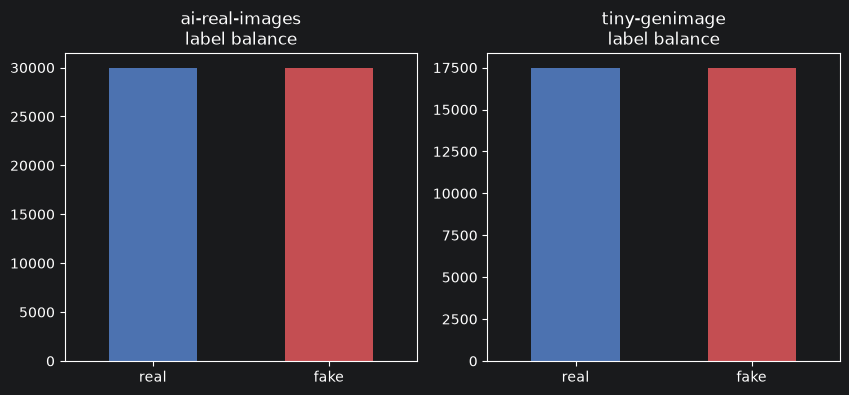

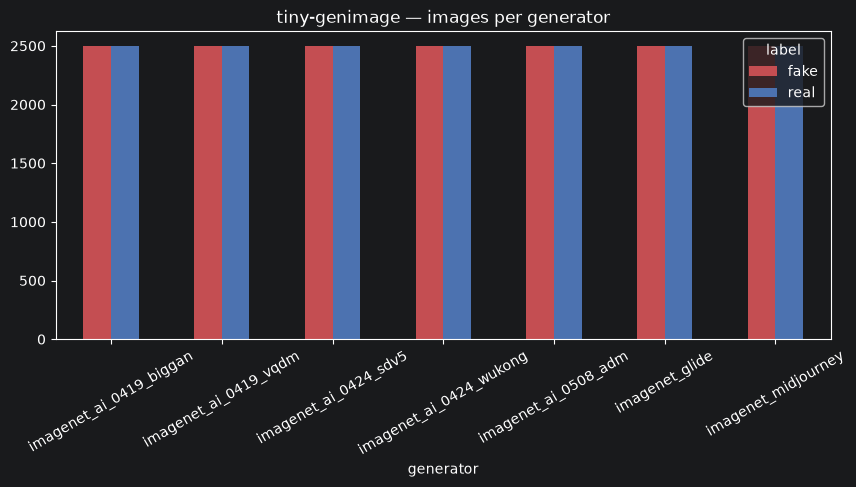

In [3]:
# Label balance per dataset (bar) + tiny-genimage per-generator real/fake counts.
fig, axes = plt.subplots(1, len(manifests), figsize=(5 * len(manifests), 4))
for ax, (name, m) in zip(axes, manifests.items()):
    m["label"].value_counts().reindex(["real", "fake"]).plot.bar(ax=ax, color=["#4c72b0", "#c44e52"])
    ax.set_title(f"{name}\nlabel balance"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
show_save(fig, "01_label_balance")

# tiny-genimage: real vs fake per generator.
tg = manifests["tiny-genimage"]
pivot = tg.groupby(["source", "label"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot.bar(ax=ax, color={"real": "#4c72b0", "fake": "#c44e52"})
ax.set_title("tiny-genimage — images per generator"); ax.set_xlabel("generator"); ax.tick_params(axis="x", rotation=30)
show_save(fig, "01_tinygenimage_per_generator")

## 2 - Sample images

Look at the data directly. First a real-vs-fake grid for each dataset, then one fake per `tiny-genimage` generator to see how different generators look.

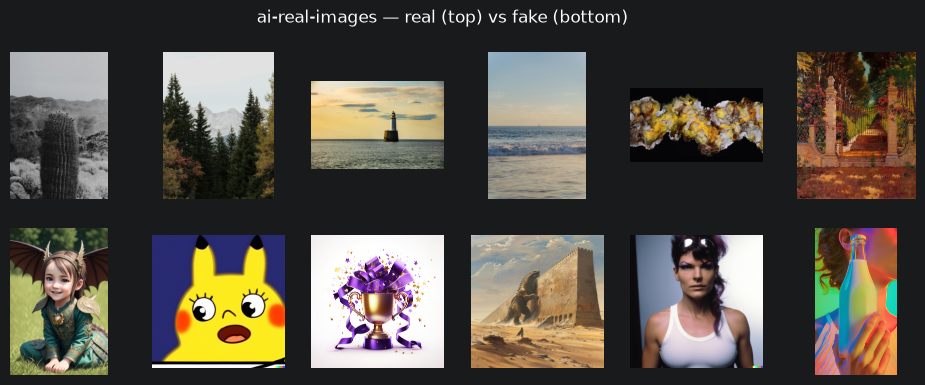

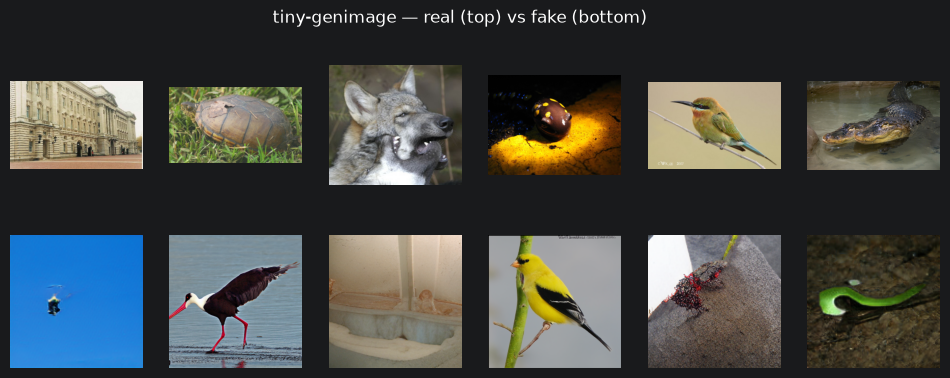

In [4]:
# Real vs fake grid (one row per label) for each dataset.
N_SHOW = 6
for name, m in manifests.items():
    fig, axes = plt.subplots(2, N_SHOW, figsize=(2 * N_SHOW, 4.2))
    for row, label in enumerate(["real", "fake"]):
        paths = sample_paths(m, label, N_SHOW)
        for col in range(N_SHOW):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(paths):
                ax.imshow(eda.read_rgb(paths[col]))
            if col == 0:
                ax.set_ylabel(label, rotation=0, labelpad=25, fontsize=11)
    fig.suptitle(f"{name} — real (top) vs fake (bottom)", fontsize=12)
    show_save(fig, f"02_samples_{name}")

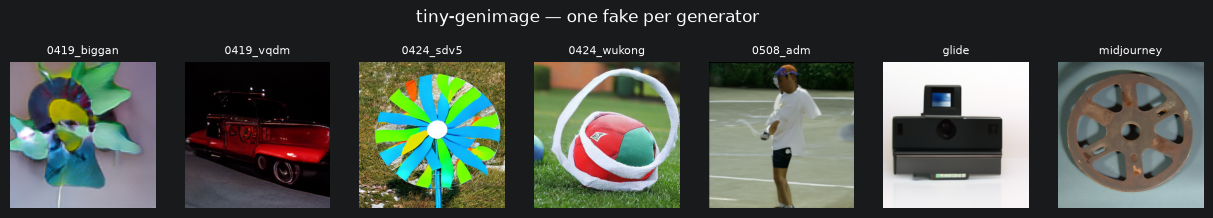

In [5]:
# One fake example per tiny-genimage generator.
gens = sorted(tg["source"].dropna().unique())
fig, axes = plt.subplots(1, len(gens), figsize=(2.2 * len(gens), 2.6))
for ax, gen in zip(axes, gens):
    fp = tg[(tg["source"] == gen) & (tg["label"] == "fake")].sample(1, random_state=SEED)["filepath"].iloc[0]
    ax.imshow(eda.read_rgb(fp)); ax.axis("off")
    ax.set_title(gen.replace("imagenet_", "").replace("ai_", ""), fontsize=8)
fig.suptitle("tiny-genimage — one fake per generator", fontsize=12)
show_save(fig, "02_tinygenimage_generators")

## 3 - Image properties (resolution, format, file size)

We scan image metadata (cheap — only reads headers) for a sample. This is where **dataset shortcuts** hide: if, say, all fakes are a fixed size (e.g. 512×512) while real photos vary, a model can "cheat" by reading resolution instead of content. We compare width/height, aspect ratio, colour mode, and file size **by label**.

In [6]:
rows = []
for name, m in manifests.items():
    for label in ["real", "fake"]:
        for fp in sample_paths(m, label, SAMPLE_META):
            info = eda.image_meta(fp)
            info.update(dataset=name, label=label)
            rows.append(info)
df_meta = pd.DataFrame(rows)
df_meta["megapixels"] = df_meta["width"] * df_meta["height"] / 1e6
df_meta["aspect"] = df_meta["width"] / df_meta["height"]
df_meta["kb"] = df_meta["bytes"] / 1024

print("colour modes:", df_meta["mode"].value_counts().to_dict())
df_meta.groupby(["dataset", "label"])[["width", "height", "megapixels", "aspect", "kb"]].describe().round(2)

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


colour modes: {'RGB': 4220, 'P': 371, 'RGBA': 184, 'L': 25}


width                                            \
                       count     mean      std    min      25%     50%   
dataset        label                                                     
ai-real-images fake   1200.0  1222.86   566.21  224.0  1024.00  1024.0   
               real   1200.0  2246.84  1879.36  265.0  1080.00  1080.0   
tiny-genimage  fake   1200.0   417.28   278.27  128.0   256.00   256.0   
               real   1200.0   481.79   218.24   84.0   375.75   500.0   

                                       height           ... aspect        \
                         75%      max   count     mean  ...    75%   max   
dataset        label                                    ...                
ai-real-images fake   1344.0   6720.0  1200.0  1170.00  ...   1.00  4.00   
               real   3675.5  12680.0  1200.0  2249.89  ...   1.50  5.91   
tiny-genimage  fake    512.0   1024.0  1200.0   417.28  ...   1.00  1.00   
               real    500.0   3072.0  1200.0   414.56  ...   1.38  8.77   

                          kb                                           \
                       count     mean      std    min     25%     50%   
dataset        label                                                    
ai-real-images fake   1200.0   431.21   600.79  12.16  130.90  221.25   
               real   1200.0  1268.89  1924.61  12.67  121.66  256.07   
tiny-genimage  fake   1200.0   343.59   412.67   9.33   76.71  125.96   
               real   1200.0   118.94   127.35   1.83   66.36  110.13   

                                         
                          75%       max  
dataset        label                     
ai-real-images fake    532.34   6731.65  
               real   2018.56  18790.13  
tiny-genimage  fake    472.28   2158.40  
               real    149.54   2216.21  

[4 rows x 40 columns]

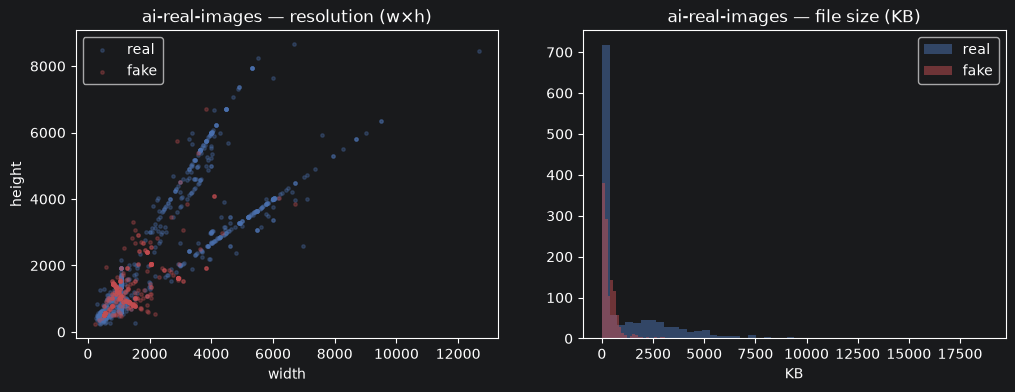

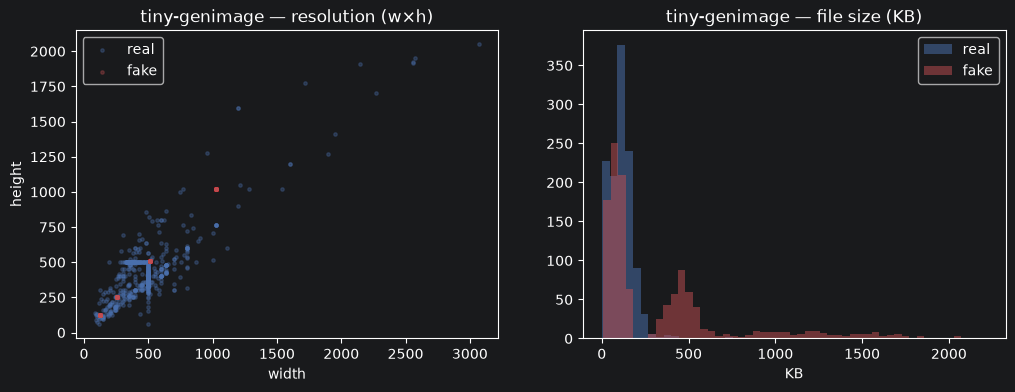

In [7]:
# Resolution scatter (w vs h) and file-size distribution, coloured by label, per dataset.
colors = {"real": "#4c72b0", "fake": "#c44e52"}
for name in manifests:
    d = df_meta[df_meta["dataset"] == name]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for label in ["real", "fake"]:
        dl = d[d["label"] == label]
        ax1.scatter(dl["width"], dl["height"], s=6, alpha=0.3, color=colors[label], label=label)
        ax2.hist(dl["kb"], bins=50, alpha=0.5, color=colors[label], label=label)
    ax1.set_title(f"{name} — resolution (w×h)"); ax1.set_xlabel("width"); ax1.set_ylabel("height"); ax1.legend()
    ax2.set_title(f"{name} — file size (KB)"); ax2.set_xlabel("KB"); ax2.legend()
    show_save(fig, f"03_properties_{name}")

## 4 - Colour & pixel statistics

Now we load a sample of images at a common size (`SIZE`×`SIZE`) so real and fake are comparable, and look for systematic colour differences: per-channel intensity distributions, the **mean image** per class (reveals colour/spatial biases), and brightness/saturation distributions. We build the sampled stacks **once** here and reuse them in the frequency section.

In [8]:
# Load reproducible sampled stacks: (dataset, label) -> uint8 array (N, SIZE, SIZE, 3).
samples = {}
for name, m in manifests.items():
    for label in ["real", "fake"]:
        paths = sample_paths(m, label, SAMPLE_STATS)
        samples[(name, label)] = np.stack([eda.read_rgb(p, size=SIZE) for p in paths])
        print(f"{name:16s} {label:4s} -> {samples[(name, label)].shape}")

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


ai-real-images   real -> (500, 128, 128, 3)
ai-real-images   fake -> (500, 128, 128, 3)
tiny-genimage    real -> (500, 128, 128, 3)
tiny-genimage    fake -> (500, 128, 128, 3)


In [9]:
# Per-channel mean / std (0-255) per (dataset, label).
stat_rows = []
for (name, label), stack in samples.items():
    f = stack.reshape(-1, 3).astype(np.float32)
    stat_rows.append({"dataset": name, "label": label,
                       "R_mean": f[:, 0].mean(), "G_mean": f[:, 1].mean(), "B_mean": f[:, 2].mean(),
                       "R_std": f[:, 0].std(), "G_std": f[:, 1].std(), "B_std": f[:, 2].std()})
pd.DataFrame(stat_rows).round(2)

,dataset,label,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,ai-real-images,real,111.000000,106.639999,98.599998,75.309998,71.199997,73.029999
1,ai-real-images,fake,118.269997,110.449997,102.980003,77.830002,73.320000,73.480003
2,tiny-genimage,real,120.589996,114.830002,103.430000,68.919998,66.790001,70.370003
3,tiny-genimage,fake,124.440002,116.430000,102.690002,70.639999,68.320000,72.730003


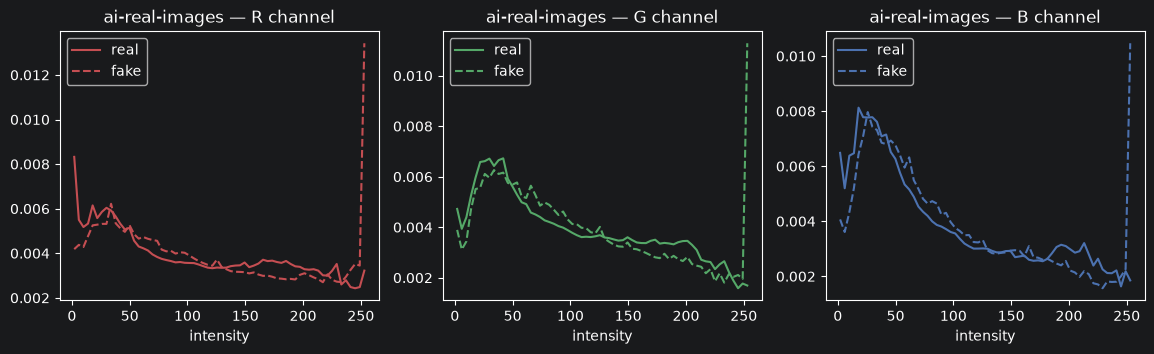

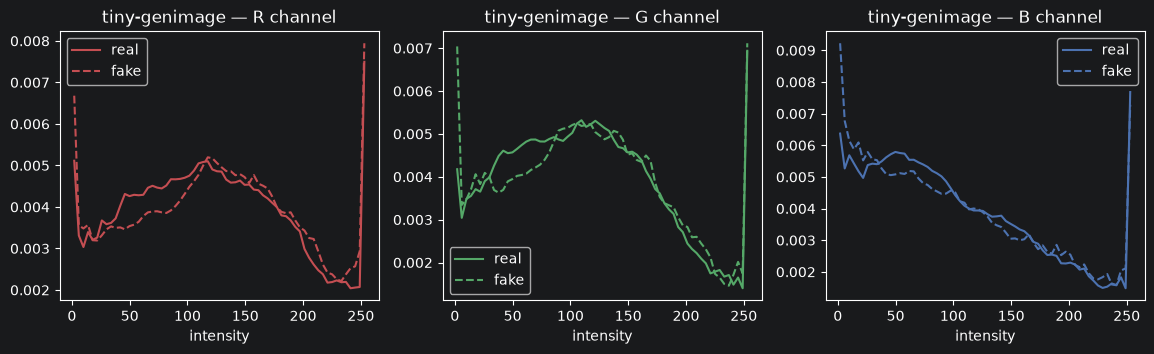

In [10]:
# Per-channel intensity histograms, real vs fake, per dataset.
channels = [("R", "#c44e52"), ("G", "#55a868"), ("B", "#4c72b0")]
for name in manifests:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ci, (cname, ccol) in enumerate(channels):
        ax = axes[ci]
        for label, ls in [("real", "-"), ("fake", "--")]:
            vals = samples[(name, label)][..., ci].ravel()
            hist, edges = np.histogram(vals, bins=64, range=(0, 255), density=True)
            ax.plot((edges[:-1] + edges[1:]) / 2, hist, ls, color=ccol, label=f"{label}")
        ax.set_title(f"{name} — {cname} channel"); ax.set_xlabel("intensity"); ax.legend()
    show_save(fig, f"04_channel_hist_{name}")

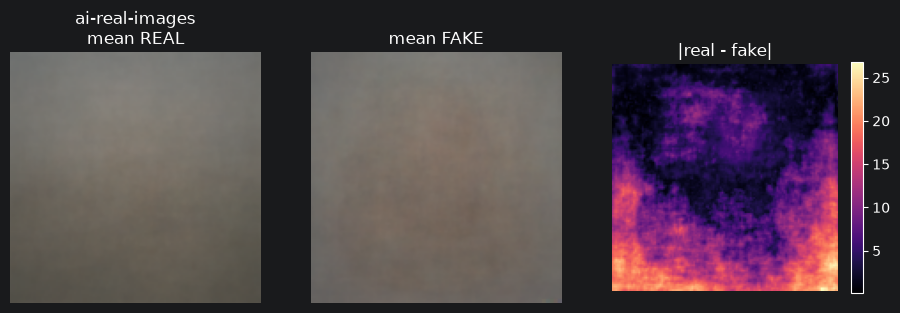

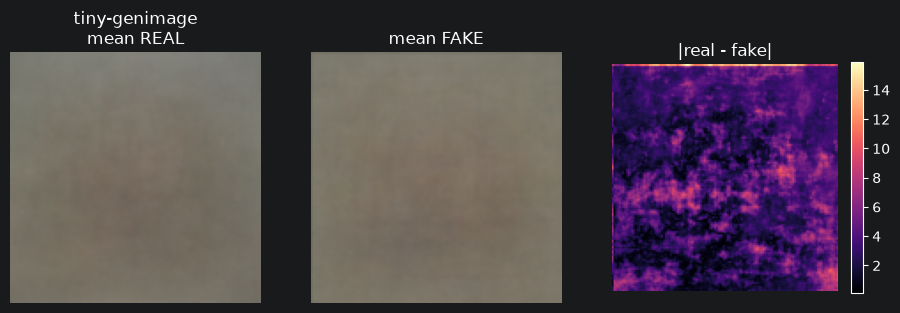

In [11]:
# Mean image per class + their difference (per dataset). Bright spots in the diff = systematic colour/spatial bias.
for name in manifests:
    mean_real = samples[(name, "real")].astype(np.float32).mean(0)
    mean_fake = samples[(name, "fake")].astype(np.float32).mean(0)
    diff = np.abs(mean_real - mean_fake).mean(-1)
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    axes[0].imshow(mean_real.astype(np.uint8)); axes[0].set_title(f"{name}\nmean REAL")
    axes[1].imshow(mean_fake.astype(np.uint8)); axes[1].set_title("mean FAKE")
    im = axes[2].imshow(diff, cmap="magma"); axes[2].set_title("|real - fake|")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    for ax in axes:
        ax.axis("off")
    show_save(fig, f"04_mean_image_{name}")

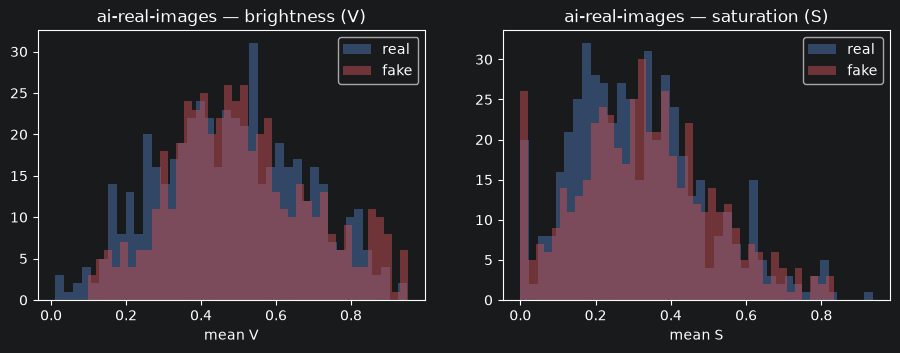

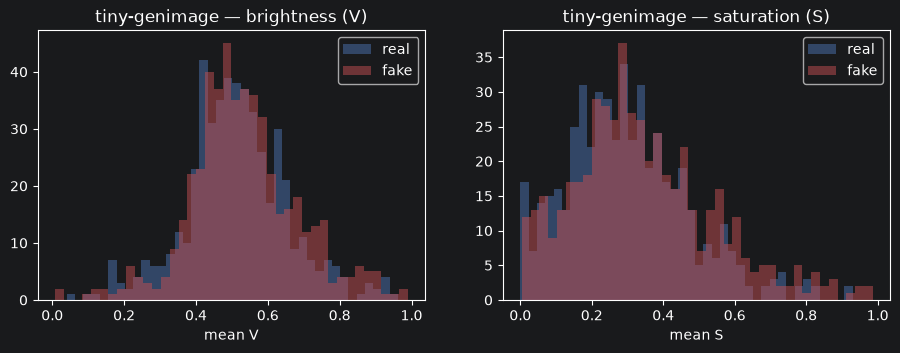

In [12]:
# Brightness (HSV value) and saturation distributions, real vs fake, per dataset.
for name in manifests:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    for label, col in [("real", "#4c72b0"), ("fake", "#c44e52")]:
        hsv = rgb_to_hsv(samples[(name, label)] / 255.0)
        sat = hsv[..., 1].mean(axis=(1, 2))   # mean saturation per image
        val = hsv[..., 2].mean(axis=(1, 2))   # mean brightness per image
        ax1.hist(val, bins=40, alpha=0.5, color=col, label=label)
        ax2.hist(sat, bins=40, alpha=0.5, color=col, label=label)
    ax1.set_title(f"{name} — brightness (V)"); ax1.set_xlabel("mean V"); ax1.legend()
    ax2.set_title(f"{name} — saturation (S)"); ax2.set_xlabel("mean S"); ax2.legend()
    show_save(fig, f"04_brightness_saturation_{name}")

## 5 - Frequency analysis (motivates `two-stream`)

Generators leave traces in the **frequency domain**: GANs add periodic high-frequency spikes; diffusion models tend to under-reproduce the finest high frequencies. We compute, per class, the **average log-power FFT spectrum** (a 2D heatmap, centred = low frequency) and its **azimuthally-averaged radial profile** (1D: energy vs spatial frequency). A consistent real-vs-fake gap here is exactly what a frequency stream can exploit.

In [13]:
# Average log-power spectrum per (dataset, label), reusing the sampled stacks.
def average_log_spectrum(stack):
    acc = np.zeros((SIZE, SIZE), dtype=np.float64)
    for img in stack:
        acc += eda.log_power_spectrum(eda.to_gray(img))
    return acc / len(stack)

spectra = {key: average_log_spectrum(stack) for key, stack in samples.items()}
print("computed average spectra for:", list(spectra))

computed average spectra for: [('ai-real-images', 'real'), ('ai-real-images', 'fake'), ('tiny-genimage', 'real'), ('tiny-genimage', 'fake')]


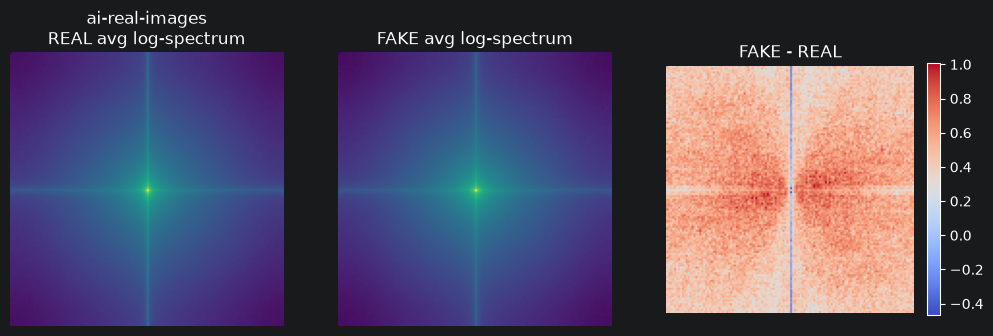

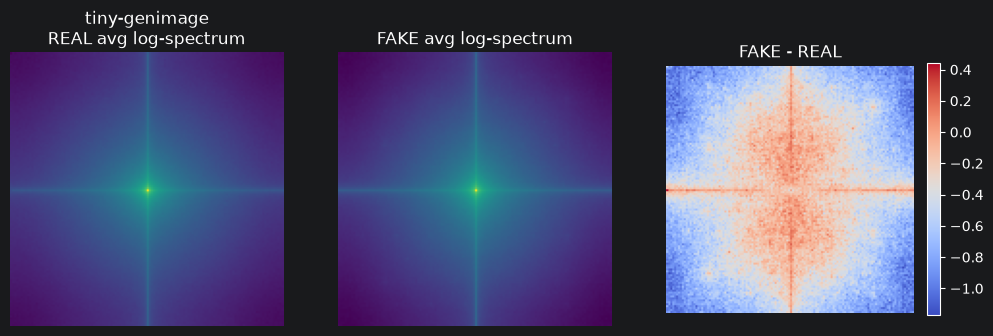

In [14]:
# 2D spectra: real, fake, and their difference (per dataset).
for name in manifests:
    sr, sf = spectra[(name, "real")], spectra[(name, "fake")]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    axes[0].imshow(sr, cmap="viridis"); axes[0].set_title(f"{name}\nREAL avg log-spectrum")
    axes[1].imshow(sf, cmap="viridis"); axes[1].set_title("FAKE avg log-spectrum")
    im = axes[2].imshow(sf - sr, cmap="coolwarm"); axes[2].set_title("FAKE - REAL")
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    for ax in axes:
        ax.axis("off")
    show_save(fig, f"05_spectrum2d_{name}")

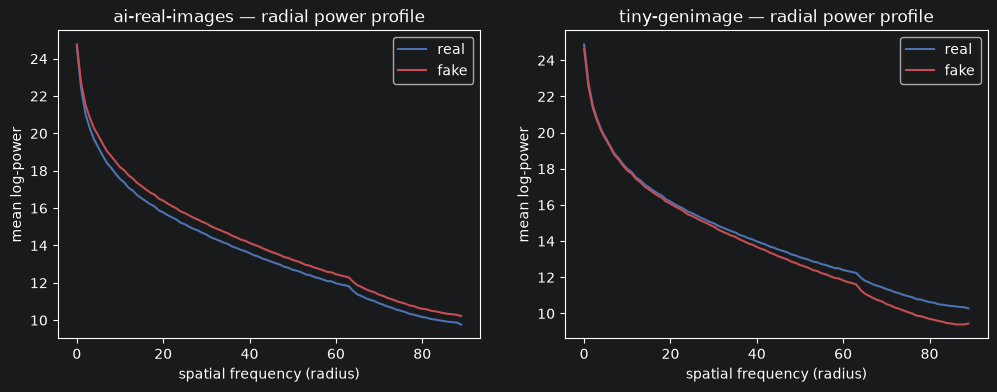

In [15]:
# Radial (azimuthally-averaged) power profile: real vs fake, per dataset.
fig, axes = plt.subplots(1, len(manifests), figsize=(6 * len(manifests), 4))
for ax, name in zip(axes, manifests):
    for label, col in [("real", "#4c72b0"), ("fake", "#c44e52")]:
        radial = eda.azimuthal_average(spectra[(name, label)])
        ax.plot(radial, color=col, label=label)
    ax.set_title(f"{name} — radial power profile")
    ax.set_xlabel("spatial frequency (radius)"); ax.set_ylabel("mean log-power"); ax.legend()
show_save(fig, "05_radial_profile")

## 6 - Embedding visualization (decompose + t-SNE)

Embed a sample of images into feature vectors, reduce to 2D, and colour by label — a quick look at whether real vs fake are **separable**, and (for `tiny-genimage`) whether **generators form distinct clusters**.

We use a **frozen CLIP image encoder** (semantic features; this previews the `clip-probe` pipeline), then **PCA → t-SNE**. Set `EMB_BACKEND = "pixels"` for a no-download raw-pixel baseline. *(t-SNE/PCA are used here for visualization only.)* The first CLIP run downloads weights (~600 MB).

Reading the plots: clean real/fake separation ⇒ in-distribution detection is easy; tight per-generator clusters in `tiny-genimage` are the generator "fingerprints" the cross-generator test later probes.

In [16]:
from utils import embed

EMB_N = 400            # images per (dataset, label) to embed
EMB_BACKEND = "clip"   # "clip" (frozen CLIP, downloads weights once) or "pixels" (no download)

if EMB_BACKEND == "clip":
    clip_model, clip_pre, clip_dev = embed.load_clip()
    print("CLIP on", clip_dev)


def embed_sample(m):
    # Balanced real/fake sample of a manifest -> (rows_df, feature_matrix).
    sub = pd.concat([
        m[m["label"] == lab].sample(min(EMB_N, int((m["label"] == lab).sum())), random_state=SEED)
        for lab in ["real", "fake"]
    ]).reset_index(drop=True)
    paths = sub["filepath"].tolist()
    if EMB_BACKEND == "clip":
        X = embed.embed_paths(paths, clip_model, clip_pre, clip_dev)
    else:
        X = embed.pixel_features(paths)
    return sub, X


emb = {name: embed_sample(m) for name, m in manifests.items()}
for name, (sub, X) in emb.items():
    print(f"{name:16s} embeddings {X.shape}")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ΜΑΤΟΥΛΑ\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\open_cl

CLIP on cpu


C:\Users\ΜΑΤΟΥΛΑ\Documents\Deepfake Detection\.venv\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


ai-real-images   embeddings (800, 512)
tiny-genimage    embeddings (800, 512)


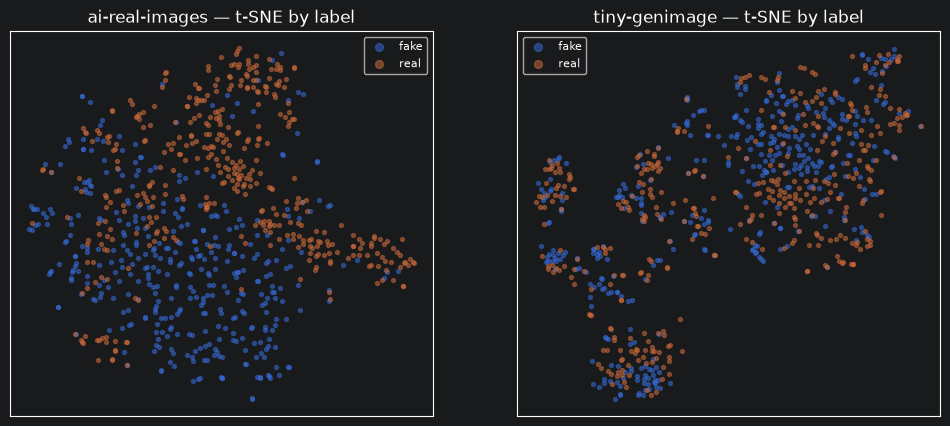

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def tsne_2d(X, seed=SEED):
    # Standardize -> PCA(50) -> t-SNE(2). PCA first is the usual t-SNE speed/stability step.
    Xs = StandardScaler().fit_transform(X)
    Xp = PCA(n_components=min(50, X.shape[1]), random_state=seed).fit_transform(Xs)
    return TSNE(n_components=2, init="pca", perplexity=30, random_state=seed).fit_transform(Xp)


def scatter_2d(ax, xy, labels, title):
    labels = pd.Series(list(labels)).reset_index(drop=True)
    for lab in sorted(labels.unique().tolist()):
        msk = (labels == lab).to_numpy()
        ax.scatter(xy[msk, 0], xy[msk, 1], s=8, alpha=0.5, label=str(lab))
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([]); ax.legend(markerscale=2, fontsize=8)


# 2D layout per dataset (reused below), coloured by label.
xys = {name: tsne_2d(X) for name, (sub, X) in emb.items()}
fig, axes = plt.subplots(1, len(emb), figsize=(6 * len(emb), 5))
axes = axes if len(emb) > 1 else [axes]
for ax, (name, (sub, X)) in zip(axes, emb.items()):
    scatter_2d(ax, xys[name], sub["label"], f"{name} — t-SNE by label")
show_save(fig, "06_tsne_by_label")

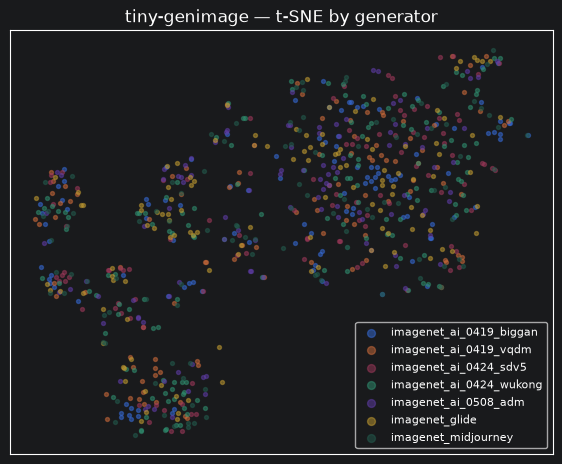

In [18]:
# tiny-genimage: same 2D layout, coloured by generator (does each generator cluster?).
sub, _ = emb["tiny-genimage"]
fig, ax = plt.subplots(figsize=(7, 5.5))
scatter_2d(ax, xys["tiny-genimage"], sub["source"], "tiny-genimage — t-SNE by generator")
show_save(fig, "06_tsne_by_generator")

## 7 - Takeaways

Key things to read off the plots (and findings already visible from a sample run):

- **Balance & structure** (§1): both datasets are exactly 50/50 real/fake; `tiny-genimage` is balanced per generator (2.5k each). Accuracy is meaningful, but we still report F1/AUC.
- **Shortcut check** (§3) — **important**: in `ai-real-images`, real images are systematically **larger and heavier** (mean ~2247 px wide / ~1269 KB) than fakes (~1223 px / ~431 KB), and fakes cluster at fixed sizes (256/512/1024). `tiny-genimage` shows the *opposite* file-size pattern. A model could exploit resolution/file-size instead of content, so we **resize everything to a fixed size** in `03_split_and_preprocessing` (and never feed file size). Also note non-RGB files (P/RGBA/L) and a few enormous images → the loader must `convert("RGB")` and tolerate them (handled).
- **Colour** (§4): fakes are slightly brighter / higher-intensity in `ai-real-images`. Easy cues a simple CNN will latch onto — and which may **not** transfer to `tiny-genimage`.
- **Frequency** (§5): look for a consistent real-vs-fake gap in the radial profile (esp. high frequency / large radius) and structure in the 2D `FAKE - REAL` map. A clear, stable gap justifies the **`two-stream`** frequency branch.
- **Embeddings** (§6): if real/fake separate cleanly in CLIP t-SNE, in-distribution detection is easy; if `tiny-genimage` **generators form distinct clusters**, that generator-fingerprint structure is exactly what the cross-generator test later probes — cues learned on `ai-real-images` may not transfer.
- **Generalization caveat**: cues strong in `ai-real-images` but absent/opposite in `tiny-genimage` foreshadow the **generalization gap** we measure later.

**Next:** `02_cleaning.ipynb` (corrupt/duplicate/leakage checks) → `03_split_and_preprocessing.ipynb` (validation split, normalization stats, canonical transforms).